In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed

Date
2020-03-16   -0.125000
2020-03-23   -0.119850
2008-07-28   -0.109296
2020-03-19   -0.097473
2020-03-18   -0.096739
Name: return, dtype: float64
Date
2008-09-19    0.146278
2008-10-13    0.130719
2008-11-25    0.127907
2020-03-17    0.118541
2020-03-25    0.115825
Name: return, dtype: float64


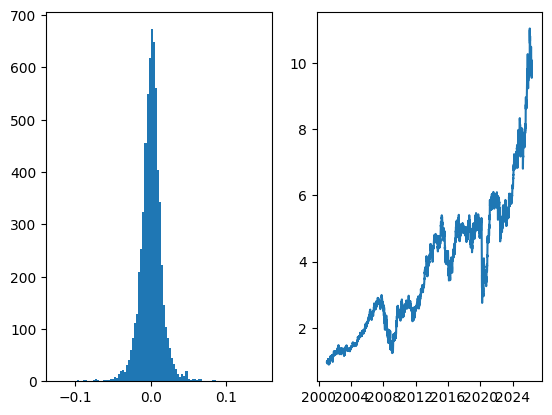

In [2]:
df = yf.download('ANZ.AX', start= '2001-01-01')
df.columns = df.columns.droplevel(1)
df['return'] = df['Close'].pct_change()
print(df['return'].nsmallest(5))
print(df['return'].nlargest(5))
fig, ax  = plt.subplots(1,2)
ax[0].hist(df['return'], bins=100)
ax[1].plot((df['return'] + 1).cumprod())

In [3]:
print(f"Kurtosis: {df['return'].kurtosis()}, Skewness: {df['return'].skew()}, Mean: {df['return'].mean()}")

Kurtosis: 9.333990215485729, Skewness: 0.15202852348087806, Mean: 0.0004702118893845868


In [4]:
annual_df = df['return'].groupby(df.index.year).std()*252**0.5
annual_df = pd.DataFrame(annual_df)
annual_df.columns = ['std']
annual_df['mean'] = df['return'].groupby(df.index.year).mean()*252
print(f"Annual Return Mean {annual_df['mean'].mean()}; Annual Volatility Mean: {annual_df['std'].mean()}")

Annual Return Mean 0.11528158266339068; Annual Volatility Mean: 0.22322769824249028


Sharpe: 0.27172632969144767


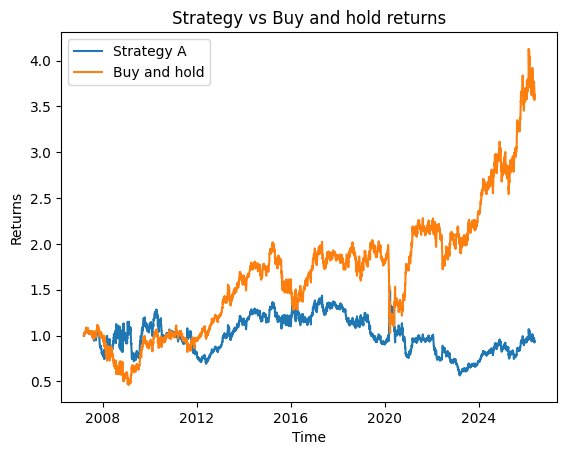

In [14]:
df['rolling'] = df['return'].rolling(200).mean()
df['signal'] = np.where(df['rolling'].shift(1)>0, 1, -1)
df = df.dropna(subset=['rolling'])
df = df.drop(df.index[0])
df['cost_appl'] = np.where(abs(df['signal'].diff())==2, 0.0025, 0)
df['stg_return'] = (df['return'] - df['cost_appl']) * df['signal']
df['stg_cum_return'] = (df['stg_return']+1).cumprod()
print(f"Sharpe: {(df['return'].mean()*252 - 0.03)/(df['return'].std()*252**0.5)}")
plt.plot((df['stg_return']+1).cumprod(), label = 'Strategy A')
plt.plot((df['return']+1).cumprod(), label= 'Buy and hold')
plt.title('Strategy vs Buy and hold returns')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()


Date
2023-03-10   -0.621494
2023-03-06   -0.614988
2023-03-08   -0.613876
2023-03-13   -0.613247
2023-03-15   -0.611719
Name: drawdown, dtype: float64


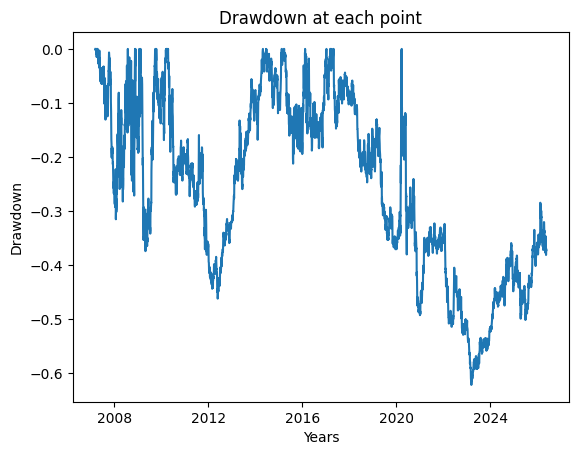

In [16]:
df['peak'] = df['stg_cum_return'].cummax()
df['drawdown'] = df['stg_cum_return']/df['peak'] - 1
plt.plot(df['drawdown'])
plt.xlabel('Years')
plt.ylabel('Drawdown')
plt.title('Drawdown at each point')
print(df['drawdown'].nsmallest(5))

###Observation:
1. Our strategy failed from buy and hold as our return was close to 0 but buy and hold made our money 6X
2. Date
2023-03-10   -0.621494
2023-03-06   -0.614988
2023-03-08   -0.613876
2023-03-13   -0.613247
2023-03-15   -0.611719
Name: drawdown, dtype: float64

Observations: 
So the signal, uh, what I created was taking the mean of last two hundred days return. And if that return is positive, then I'll buy on the day. And if, uh, it is negative, I will short it. And the look back I used was the average only. So the average of last two hundred days. return. The strategy returned only one x harmony, so the, um, whatever the money we started with it with it returned the same amount of money. But for buy and hold, the money grew up four point five times. It failed because, um, uh, it is taking the average of last two hundred days. And in year two thousand twenty, when the market crashed a lot, it started taking that take in account that values where the return was negative. And in two thousand twenty one, the market started recovering very fast. And when our strategy was predicting too short, the market was increasing a lot. So we lost huge sum of money over there and cannot recover from there. So if I want to improve it, I would think of checking the regime if if I... I'll I'll see both long term average and the short term average. if I see the short term average is a lot different thn the long term or are opposite we can base the strategy to short term average. It doesnot have any edge in the market right now but will surely have when I take in consideration short term average as well.